# Market Seams on the WSCC 9-Bus Network

This notebook builds a unified WSCC 9-bus nodal clearing, then partitions the
network into two market footprints that clear independently, to study three
seams issues: dispatch interference, inefficient accommodation of flows, and
inefficient interchange.

The Western System Coordinating Council (WSCC) 9-bus test represents a simple approximation of the Western System Coordinating Council (WSCC) to an equivalent system with nine buses, three loads, and three generators.

| Section | What it shows |
|---|---|
| **0-2. Shared network, shift factors, unified clearing** | DC power flow, nodal LMPs $\lambda_n$, and the per-line congestion-rent decomposition |
| **3. Two market footprints** | The partition, the two seam lines, and the flow each market computes |
| **4. Dispatch interference** | Each market within its own limits; the wire carries the sum |
| **5. Inefficient accommodation** | Reserving room for the other market's flows restores feasibility, at a cost |
| **6. Inefficient interchange** | A scheduled, price-taking transfer faces the seam dual gap |
| **7. The seam ledger** | Autarky, partial trade, fuller trade, and unified clearing compared |
| **8. Sandbox** | Knobs for footprints, costs, ratings, interchange |

All computation uses [`seams_engine.py`](seams_engine.py). The cheap generation
sits in **Market A** (bus 3 \$20 and bus 2 \$35), so Market A exports across the
seam to **Market B**, whose only unit (bus 1 \$50) is dear — that price gap is
what trade across the seam is worth.

## 0. Setup

In [ ]:
#@title ▶ Run me first — Colab setup (installs packages, fetches the helper modules)
# On Google Colab this installs the few non-default packages and downloads the
# three helper modules next to the notebook. Running locally it does nothing
# (the modules are already on disk), so the same notebook works in both places.
import sys, subprocess

def _sh(cmd):
    print("$", cmd)
    subprocess.run(cmd, shell=True, check=True)

if "google.colab" in sys.modules:
    _sh("pip install -q pypsa pandapower pycirclize")
    _base = "https://raw.githubusercontent.com/pdockery/wscc9-illustrative-model/main"
    for _f in ("ieee9_network.py", "seams_engine.py", "nodal_plot.py"):
        _sh(f"wget -q {_base}/{_f} -O {_f}")
    print("Colab setup complete.")
else:
    print("Local run: using the modules already in this folder.")


In [2]:
import sys, os, importlib
import warnings; warnings.filterwarnings('ignore')
import logging; logging.getLogger('pypsa').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))

from ieee9_network import build_ieee9_network
import seams_engine, nodal_plot
importlib.reload(seams_engine); importlib.reload(nodal_plot)
from seams_engine import (
    compute_ptdf, MarketEngine, solve_engine_dispatch,
    physical_flows, seam_dual_gap, to_supply_demand, susceptance_widths,
)
from nodal_plot import (
    plot_network_topology, plot_nodal_circlize,
    assign_bus_colors, BUS_PALETTE, TRANSIT_COLOR,
)
pd.set_option('display.width', 160)

# Clean tables on PDF export: give DataFrames/Series a booktabs LaTeX rendering.
# Jupyter and Colab still show the normal HTML tables; `nbconvert --to pdf` picks
# up this text/latex representation, so tables come out as real ruled tables
# (wide ones scaled to the text width) instead of wrapped monospace.
def _df_to_latex(_df):
    if isinstance(_df, pd.Series):
        _df = _df.to_frame()
    _body = _df.to_latex(escape=True, na_rep='', float_format=lambda v: f'{(0.0 if v==0 else v):,.6g}')
    _ncol = _df.shape[1] + _df.index.nlevels
    if _ncol > 6:   # wide -> scale to text width so nothing runs off the page
        return '\\begin{center}\\resizebox{\\linewidth}{!}{%\n' + _body + '}\\end{center}'
    return '\\begin{center}{\\small\n' + _body + '}\\end{center}'

try:
    _ltx = get_ipython().display_formatter.formatters['text/latex']
    _ltx.for_type(pd.DataFrame, _df_to_latex)
    _ltx.for_type(pd.Series, _df_to_latex)
except Exception:
    pass

print('ready')

ready

### Generation & load table

The 9-bus system has three generators and three
loads. 

```
        (1)gen $50            (3)gen $20
          |                     |
         [4]---[5]load--------[6]---[7]load
          |                     |
         [9]load---[8]---------/
                    |
                  (2)gen $35
```
Lines (rating MW): `0:1-4(250) 1:4-5(250) 2:5-6(150) 3:3-6(300) 4:6-7(150) 5:7-8(250) 6:8-2(250) 7:8-9(250) 8:9-4(250)`

In [3]:
# Resource stack and loads on the shared network
GEN_FLEET = {
    'gen_slack_0': {'bus': '1', 'cost': 50.0, 'p_nom': 250.0},   # dear unit
    'gen_0':       {'bus': '2', 'cost': 35.0, 'p_nom': 300.0},   # mid-merit
    'gen_1':       {'bus': '3', 'cost': 20.0, 'p_nom': 170.0},   # cheapest unit
}
LOADS = {'5': 90.0, '7': 100.0, '9': 125.0}

# Circlize sector order: clockwise from 12 o'clock, following the network ring
# so the chord diagram reads in the same spatial order as the topology diagram.
RING_ORDER = ['3', '6', '7', '8', '2', '9', '4', '1', '5']

# Orientation, applied to ALL node + circlize plots so they read alike:
#  - node diagram rotated 180deg  -> bus 3 at the bottom, bus 2 NW, bus 9 at top;
#  - circlize centred on bus 9    -> bus 9 across 12 o'clock, bus 3 near the bottom.
ROTATION_DEG = 180
CENTER_BUS = '9'
COORDS = nodal_plot.rotate_coords(nodal_plot.IEEE9_COORDS, ROTATION_DEG)

def build_network(line_ratings=None):
    # Build the 9-bus PyPSA network, applying any line-rating overrides.
    n = build_ieee9_network(periods=1)
    for ln, mw in (line_ratings or {}).items():
        n.lines.loc[ln, 's_nom'] = float(mw)
    return n

def make_engine(name, buses, activated='all'):
    # Assign every fleet gen and load whose bus is in `buses` to this engine.
    buses = {str(b) for b in buses}
    gens = {g: dict(s) for g, s in GEN_FLEET.items() if str(s['bus']) in buses}
    loads = {b: mw for b, mw in LOADS.items() if b in buses}
    return MarketEngine(name=name, gens=gens, loads=loads, activated_lines=activated)

print('fleet:', {g: (s['bus'], s['cost'], s['p_nom']) for g, s in GEN_FLEET.items()})
print('loads:', LOADS)
print('ring order:', RING_ORDER, '| rotation', ROTATION_DEG, 'deg | centre bus', CENTER_BUS)

fleet:

{'gen_slack_0': ('1', 50.0, 250.0), 'gen_0': ('2', 35.0, 300.0), 'gen_1': ('3', 20.0, 170.0)}

loads:

{'5': 90.0, '7': 100.0, '9': 125.0}

ring order:

['3', '6', '7', '8', '2', '9', '4', '1', '5']

| rotation

180

deg | centre bus

9

## 1. Shared network & shift factors

> *A net injection of $p$ MW at bus $n$ produces an incremental flow of
> $SF_{n,m}\,p$ on constraint $m$.*

Each engine's flow $F^M_m=\sum_n SF_{n,m}\,p^{\text{inj},M}_n$
and the LMP congestion term $\sum_m SF_{n,m}\mu_m$ is built.

In [4]:
pt = compute_ptdf(build_network(), slack_bus='1')
SF = pd.DataFrame(pt.ptdf,
                  index=[f'{l} ({a}-{b})' for l, (a, b) in zip(pt.lines, pt.line_buses)],
                  columns=[f'bus {b}' for b in pt.buses]).round(3)
print('Shift-factor matrix  SF[line, bus]   (slack = bus 1, so its column is 0 by definition)')
print(SF)


# Canonical per-bus colours: assigned ONCE from the full fleet (which buses host
# gen/load), so every figure -- unified, scenario, or independent per-BA -- uses
# the SAME colour for a given bus. A subset clearing (e.g. one BA alone) no longer
# restarts the palette and reshuffles colours.
_sup_full = {}
for _g, _s in GEN_FLEET.items():
    _sup_full.setdefault(_s['bus'], []).append(_s)
BUS_COLORS = assign_bus_colors(pt.buses, _sup_full, LOADS)


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Shift-factor matrix  SF[line, bus]   (slack = bus 1, so its column is 0 by definition)

              bus 1  bus 2  bus 3  bus 4  bus 5  bus 6  bus 7  bus 8  bus 9
line_0 (1-4)    0.0 -1.000 -1.000   -1.0 -1.000 -1.000 -1.000 -1.000 -1.000
line_1 (4-5)    0.0 -0.361 -0.615   -0.0 -0.865 -0.615 -0.467 -0.361 -0.125
line_2 (5-6)    0.0 -0.361 -0.615   -0.0  0.135 -0.615 -0.467 -0.361 -0.125
line_3 (3-6)    0.0  0.000  1.000   -0.0  0.000  0.000 -0.000  0.000  0.000
line_4 (6-7)    0.0 -0.361  0.385    0.0  0.135  0.385 -0.467 -0.361 -0.125
line_5 (7-8)    0.0 -0.361  0.385   -0.0  0.135  0.385  0.533 -0.361 -0.125
line_6 (8-2)    0.0 -1.000  0.000    0.0  0.000  0.000  0.000  0.000  0.000
line_7 (8-9)    0.0  0.639  0.385    0.0  0.135  0.385  0.533  0.639 -0.125
line_8 (9-4)    0.0  0.639  0.385    0.0  0.135  0.385  0.533  0.639  0.875

### Line admittance map

The WSCC 9-bus assigns a distinct reactance $x_m$ to every line. For DC flow the
power a line carries per unit of angle difference across its **susceptance**
$b_m = 1/x_m$. The cell below draws each line with a width
proportional to $b_m$ (wider = lower $x$ = more admittance), giving a physical
picture of where power prefers to flow before any dispatch is chosen. 

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


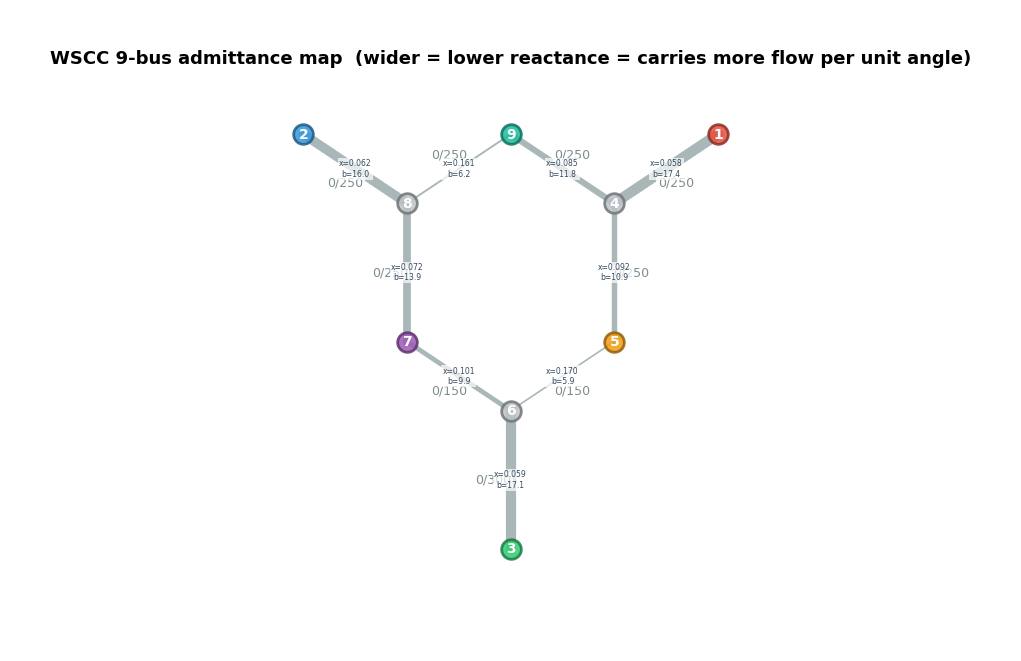

,x (reactance),b = 1/x,draw width
line_0 (1-4),0.0576,17.36,7.50
line_3 (3-6),0.0586,17.06,7.34
line_6 (8-2),0.0625,16.00,6.75
line_5 (7-8),0.0720,13.89,5.59
line_8 (9-4),0.0850,11.76,4.43
line_1 (4-5),0.0920,10.87,3.94
line_4 (6-7),0.1008,9.92,3.42
line_7 (8-9),0.1610,6.21,1.38
line_2 (5-6),0.1700,5.88,1.20


In [5]:
pt = compute_ptdf(build_network(), slack_bus='1')
widths = susceptance_widths(pt, wmin=1.2, wmax=7.5)   # {line: linewidth} from b = 1/x

# Colour the nodes with the SAME per-bus palette used throughout the notebook:
# gen/load buses take their palette colour, pure transit buses stay grey. The
# membership comes from the fleet (not the dispatch), so these node colours match
# the dispatched figures exactly -- this is purely a susceptance map, no flows.
node_colors = BUS_COLORS   # canonical per-bus palette (defined with pt above)

# Pure susceptance map: no dispatch annotations, no flows -- width encodes
# admittance only, nodes carry the standard palette colour.
fig, ax = plot_network_topology(
    build_network(), supply_by_bus={}, demand_by_bus={},
    bus_colors=node_colors, bus_coords=COORDS,
    line_flows={l: 0.0 for l in pt.lines},   # 0 flow -> no arrows, grey lines
    line_widths=widths,
    title='WSCC 9-bus admittance map  (wider = lower reactance = carries more flow per unit angle)',
)
# annotate each line with its x and b
for l, (b0, b1) in zip(pt.lines, pt.line_buses):
    x0, y0 = COORDS[b0]; x1, y1 = COORDS[b1]
    xm, ym = (x0 + x1) / 2, (y0 + y1) / 2
    b = pt.susceptance[pt.line_idx[l]]
    ax.text(xm, ym, f'x={1/b:.3f}\nb={b:.1f}', fontsize=5.5, ha='center', va='center',
            color='#34495E', bbox=dict(fc='white', ec='none', alpha=0.7, pad=0.8), zorder=6)
plt.show()

pd.DataFrame({
    'x (reactance)': [round(1 / pt.susceptance[pt.line_idx[l]], 4) for l in pt.lines],
    'b = 1/x': [round(pt.susceptance[pt.line_idx[l]], 2) for l in pt.lines],
    'draw width': [round(widths[l], 2) for l in pt.lines],
}, index=[f'{l} ({a}-{b})' for l, (a, b) in zip(pt.lines, pt.line_buses)]).sort_values('b = 1/x', ascending=False)

## 2. One engine — the unified clearing

### The dispatch each engine solves, its Lagrangian, and the bus prices

`solve_engine_dispatch` clears **one engine's** DC-OPF on the shared network: a
bid-based security-constrained economic dispatch (SCED) reduced to a **single
period with energy-cost bids only** (no unit commitment) and a **single
system-wide energy balance**. An engine $M$ brings its resources $\mathcal R^M$
(cost $c_i$, cap $\bar g_i$ at bus $\mathrm{bus}(i)$), its served load $d_n$, an
activated line set $\mathcal M^M_{\mathrm{act}}$, and any **exogenous** cross-seam
schedule $\mathrm{exo}_n$ (zero for a stand-alone clear).

**Objective — minimise the engine's own dispatch cost.**

$$\min_{0\le g_i\le \bar g_i}\ \ C^M=\sum_{i\in\mathcal R^M} c_i\,g_i. \qquad\qquad(1)$$

*In words.* Stack up the engine's own generators cheapest-first to cover its obligation
(no-load, start-up and shut-down terms drop out in this single-period, energy-only cut).

**Energy balance — its dual is the energy price $\lambda^M$.**

$$\sum_{i\in\mathcal R^M} g_i=\sum_n d_n-\sum_n \mathrm{exo}_n,\   \ [\lambda^M]\qquad\qquad(2)\quad$$

*In words.* The engine's generation serves its own load net of any scheduled interchange:
$\mathrm{exo}_n>0$ is power injected into the footprint (an import), $\mathrm{exo}_n<0$ a
withdrawal (an export). $\lambda^M$ is the single system-wide energy price (`res.energy_price`).

**Flow and activated limits — duals $\mu^M_m$.**

$$F^M_m=\sum_n SF_{n,m}\,p^{\mathrm{inj},M}_n,\qquad
  -\bar F_m\le F^M_m\le \bar F_m\ \ [\mu^M_m]\ \ (m\in\mathcal M^M_{\mathrm{act}}),\qquad
  p^{\mathrm{inj},M}_n=\!\!\!\sum_{i\in\mathcal R^M:\,\mathrm{bus}(i)=n}\!\!\!g_i-d_n+\mathrm{exo}_n. \qquad(3)$$

*In words.* The engine's flow on a line is the shift-factor-weighted sum of **its own** net
injections, held within the rating **only on the lines it activates**. A line outside
$\mathcal M^M_{\mathrm{act}}$ has its limit relaxed and stays silent (`activated_lines`).

**The Lagrangian.**

$$\mathcal L^M(g,\lambda^M,\mu^M,\underline\mu^M,\overline\mu^M)=\sum_i c_i\,g_i-\lambda^M\!\Big(\sum_i g_i-\sum_n d_n+\sum_n\mathrm{exo}_n\Big)-\!\!\sum_{m\in\mathcal M^M_{\mathrm{act}}}\!\!\mu^M_m\,F^M_m+\sum_i\overline\mu^M_i\,(g_i-\bar g_i)-\sum_i\underline\mu^M_i\,g_i. \qquad(4)$$

*In words.* Cost, minus the energy-balance multiplier times the imbalance, minus each activated
line's (signed) congestion multiplier times the flow on it, plus one multiplier per generator
capacity limit: $\overline\mu^M_i\ge 0$ on the upper limit $g_i\le\bar g_i$ and
$\underline\mu^M_i\ge 0$ on the lower limit $g_i\ge 0$. $\lambda^M$ and the $\mu^M_m$ are exactly
`res.energy_price` and `res.line_dual`.

**Complementary slackness.** Each capacity multiplier is non-zero only when its own limit binds:

$$\overline\mu^M_i\,(g_i-\bar g_i)=0,\qquad \underline\mu^M_i\,g_i=0,\qquad \overline\mu^M_i,\underline\mu^M_i\ge 0.$$

A fully-loaded unit ($g_i=\bar g_i$) may carry $\overline\mu^M_i>0$, an idle unit ($g_i=0$) may
carry $\underline\mu^M_i>0$, and a **marginal** unit ($0<g_i<\bar g_i$) has both equal to zero.

**Stationarity — where the price comes from.** At the optimum the Lagrangian is stationary in
each dispatch variable. For a generator $i$ at bus $n=\mathrm{bus}(i)$, using $\partial F^M_m/\partial g_i=SF_{n,m}$:

$$\frac{\partial \mathcal L^M}{\partial g_i}
  = c_i-\lambda^M-\!\!\sum_{m\in\mathcal M^M_{\mathrm{act}}}\!\!SF_{n,m}\,\mu^M_m\;+\;\overline\mu^M_i-\underline\mu^M_i\;=\;0 .$$

For a **marginal** unit the two bound multipliers vanish by complementary slackness, so the
$\overline\mu^M_i-\underline\mu^M_i$ term drops and we are left with
$c_i=\lambda^M+\sum_{m}SF_{n,m}\,\mu^M_m$.

**Nodal LMP — the price at every bus.**

$$\lambda^M_n=\lambda^M+\sum_{m\in\mathcal M^M_{\mathrm{act}}}SF_{n,m}\,\mu^M_m. \qquad\qquad(5)$$

*In words.* A bus's price is the system energy price plus, for every binding activated line, that
line's shadow price scaled by the bus's shift factor onto it. With nothing binding, every bus
collapses to the one price $\lambda^M$. **Section 2 runs the unified counterfactual**: a single
engine over **all** buses with $\mathrm{exo}=0$ and every limit enforced — the single-price
benchmark the rest of the notebook builds on.

### Congestion rent

Unified clearing is the single engine over **all** buses ($\mathrm{exo}=0$, every
line activated), so we drop the engine superscript: write $\lambda_n\equiv\lambda^M_n$,
$\mu_l\equiv\mu^M_l$, and $\mathcal M_{\mathrm{act}}$ for the activated set. Value each binding
line's limit at its shadow price which is equivalent to the net the bus-level payments:

$$R=\sum_{l\in\mathcal M_{\mathrm{act}}}|\mu_l|\,|F_l|
   =\underbrace{\sum_n\lambda_n d_n}_{\text{paid by load}}
   -\underbrace{\sum_n\lambda_n g_n}_{\text{paid to generation}}. \qquad (6)$$

*In words.* The congestion rent (merchandising surplus) is the shadow price of each binding
line times the power on it — and it equals exactly what load pays minus what generation is
paid, because the energy components net to zero (total generation $=$ total load). **No
binding line $\Rightarrow$ no price separation $\Rightarrow R=0$.** 

**Edit below:** generator costs, load levels, and line ratings. Limiting a line rating may
create congestion and price separation on the constrained
path.

In [6]:
# -- EDIT -- unified-clearing inputs --------------------------------------
COST_OVERRIDE   = {}                      # e.g. {'gen_0': 45.0} to re-bid the $35 unit
LOAD_OVERRIDE   = {}                      # e.g. {'7': 130.0}
LINE_RATINGS    = {'line_4': 40.0}   # adjust line_4 (6-7, internal to BA-1) below its ~63 MW natural flow
# -------------------------------------------------------------------------

net = build_network(LINE_RATINGS)
pt  = compute_ptdf(net, slack_bus='1')

unified = make_engine('UNIFIED', buses=pt.buses)
for g, c in COST_OVERRIDE.items(): unified.gens[g]['cost'] = c
for b, v in LOAD_OVERRIDE.items(): unified.loads[b] = v

res = solve_engine_dispatch(pt, unified)
print('dispatch (MW):', {k: round(v, 1) for k, v in res.dispatch.items()})
print('energy price :', round(res.energy_price, 2), '$/MWh')
binding = {k: round(v, 1) for k, v in res.line_dual.items() if abs(v) > 1e-3}
print('binding lines:', binding or 'none')
print()
print('LMP by bus ($/MWh):')
pd.Series({b: round(res.lmp[b], 2) for b in pt.buses}).to_frame('LMP').T

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


dispatch (MW):

{'gen_slack_0': 0.0, 'gen_0': 176.1, 'gen_1': 138.9}

energy price :

27.74

$/MWh

binding lines:

{'line_4': -20.1}

LMP by bus ($/MWh):

,1,2,3,4,5,6,7,8,9
LMP,27.74,35.0,20.0,27.74,25.02,20.0,37.13,35.0,30.25


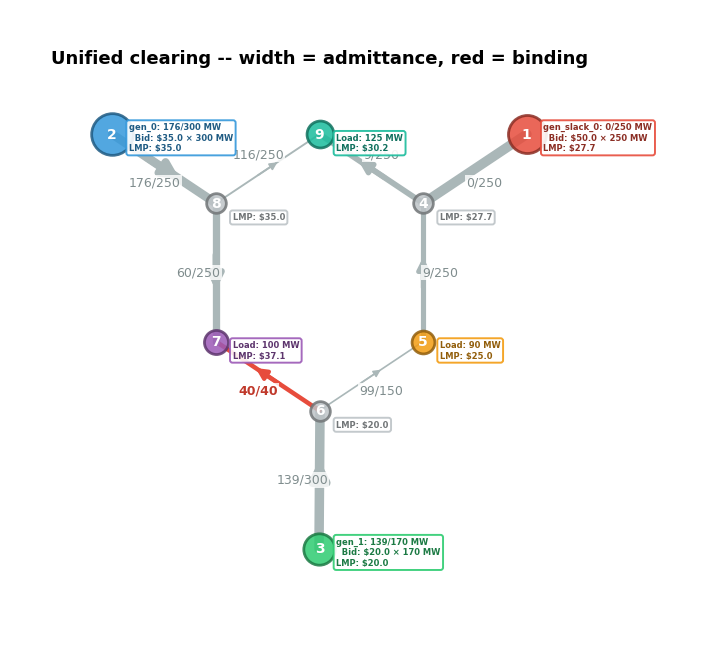

In [7]:
# Topology with DC power flow. Line WIDTH = susceptance (b=1/x); line COLOUR =
# congestion. A line is red only when its shadow price is non-zero (a genuine
# binding transmission limit) -- NOT merely when flow hits rating, which can
# happen because the generator behind a radial line is maxed out.
sup, dem = to_supply_demand(unified, res)
colors = dict(BUS_COLORS)   # canonical colours; a subset clearing no longer reshuffles them
flows = {l: res.flow_own[l] for l in pt.lines}
binding_lines = {l for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
fig, ax = plot_network_topology(
    net, sup, dem, bus_colors=colors, bus_lmps=res.lmp, line_flows=flows,
    line_widths=susceptance_widths(pt), constrained_lines=binding_lines, bus_coords=COORDS,
    title='Unified clearing -- width = admittance, red = binding',
)
plt.show()

### Nodal merit-order + dispatch view, and the congestion shadow price

The circlize / chord view, built here from the unified DC-OPF. Each sector is a bus. The bar's height for a generator is that unit's marginal cost (its bid) -- solid
where dispatched, faded where it is available capacity. A **dashed line is drawn across each
bus at its cleared LMP**; the gap between a dispatched bar's top and that line is the unit's
**inframarginal rent** (LMP - marginal cost), while a bar rising *above* the line is out of
merit at this price and stays undispatched. The bar's height for a demand bus is drawn at LMP height, and the
**chords** are PTDF-traced generator→load deliveries. Below the figure we print the
congestion shadow price $\mu_m$ on each binding line — the dual of the binding-line
limit, and the exact quantity that splits the LMPs through $\sum_m SF_{n,m}\,\mu_m$.

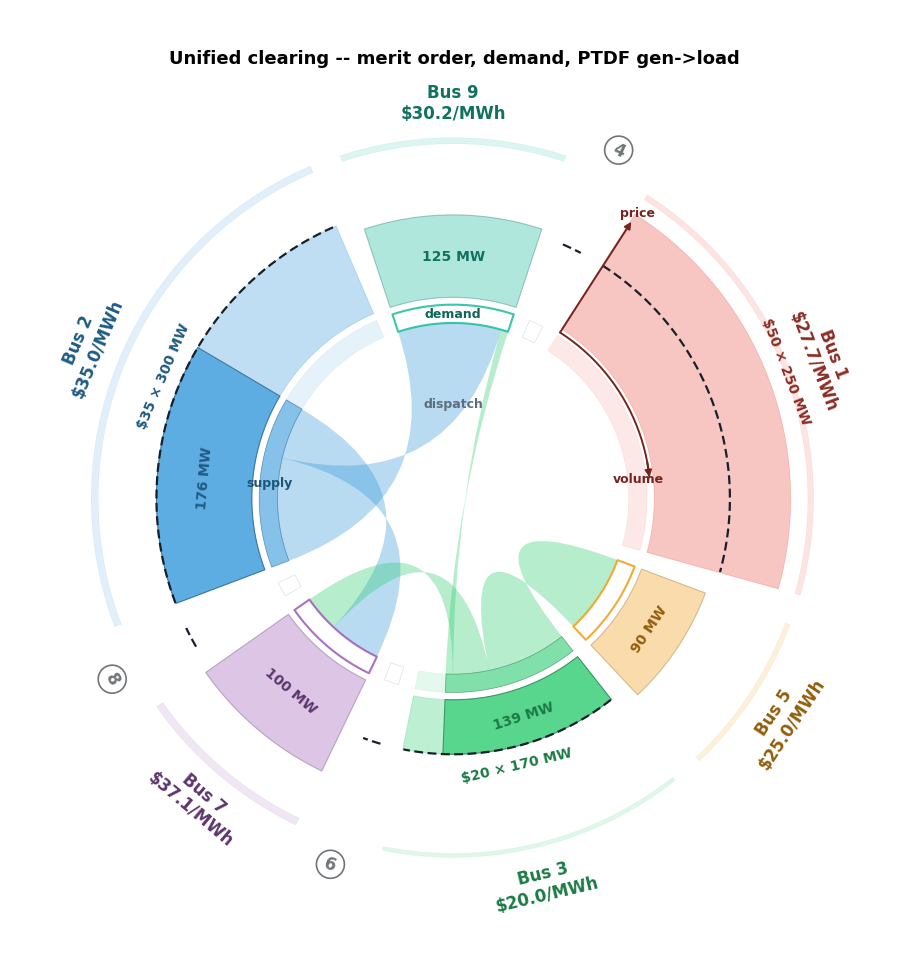

Binding transmission constraints -- congestion shadow price |mu_m|:

  line_4 (6-7): |mu| = $20.10/MWh   (flow +40 MW at the 40 MW limit)


Settlement by node  (payments to generation vs payments by load):

,LMP ($/MWh),gen (MW),paid to gen ($/h),load (MW),paid by load ($/h)
bus,,,,,
1,27.74,0.0,0.0,0.0,0.0
2,35.0,176.1,6162.4,0.0,0.0
3,20.0,138.9,2778.6,0.0,0.0
4,27.74,0.0,0.0,0.0,0.0
5,25.02,0.0,0.0,90.0,2251.8
6,20.0,0.0,0.0,0.0,0.0
7,37.13,0.0,0.0,100.0,3712.6
8,35.0,0.0,0.0,0.0,0.0
9,30.25,0.0,0.0,125.0,3780.8


Congestion rent  =  paid by load  -  paid to gen  =  9,745.2  -  8,941.0  =  $804.2/h

...

(equal by the LMP decomposition: the energy component nets to zero because total gen = total load,
 so only the congestion term survives, and it equals mu x flow on each binding line.)


Marginal value of line capacity  (shadow price x flow, per line):

,from,to,flow (MW),rating (MW),binding,|mu| ($/MWh = value of +1 MW),rent |mu| x flow ($/h)
line,,,,,,,
line_0,1,4,-0.0,250.0,False,0.0,0.0
line_1,4,5,-8.9,250.0,False,0.0,0.0
line_2,5,6,-98.9,150.0,False,0.0,0.0
line_3,3,6,138.9,300.0,False,0.0,0.0
line_4,6,7,40.0,40.0,True,20.1,804.1
line_5,7,8,-60.0,250.0,False,0.0,0.0
line_6,8,2,-176.1,250.0,False,0.0,0.0
line_7,8,9,116.1,250.0,False,0.0,0.0
line_8,9,4,-8.9,250.0,False,0.0,0.0


The |mu| column is the value of relaxing each line by 1 MW; only binding lines carry a positive value.
The rent column decomposes the congestion rent above by line and totals $804.1/h.


wrote seams_settlement_by_node.csv  and  seams_line_capacity_value.csv  to  C:\Users\docke\Projects\ASSUME\assume\testbed

In [8]:
# Circlize / chord view of the unified clearing (reuses sup, dem, colors, res from above).
flow_list = nodal_plot.compute_ptdf_flows(net, sup, dem)   # PTDF-traced gen->load chords

fig = plot_nodal_circlize(
    sup, dem, pt.buses,
    flows=flow_list,
    clearing_price=res.energy_price,
    bus_lmps=res.lmp,
    bus_colors=colors,
    lmp_line=True,   # dashed line = bus LMP; solid bar height = unit marginal cost (gap = inframarginal rent)
    annotate_roles=True,   # one-time supply/demand/transfers key near 12 o'clock
    axis_key=True,         # illustrative price (up) / volume (across) L-axis in the corner
    sector_order=RING_ORDER,   # clockwise from 12 o'clock, following the network ring
    center_bus=CENTER_BUS,     # bus 9 centred at 12 o'clock (matches the rotated node diagram)
    figsize=(8.5, 9.0),        # fills the width of an 8.5x11 page (extra height -> title headroom)
    label_fontsize=12,         # outer sector labels (Bus N / LMP)
    track_fontsize=10,         # in-track bid / dispatch / load-MW labels, >= 10 pt
    show_legend=False,         # per-bus gen/load/LMP already on the ring + in-track; legend was sub-10 pt and duplicative
    title='Unified clearing -- merit order, demand, PTDF gen->load',
)
plt.show()

# Shadow price of the binding line constraint(s): the congestion dual mu_m.
binding = {l: mu for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
if binding:
    print('Binding transmission constraints -- congestion shadow price |mu_m|:')
    for l, mu in sorted(binding.items(), key=lambda kv: -abs(kv[1])):
        i = pt.line_idx[l]; a, b = pt.line_buses[i]
        print(f'  {l} ({a}-{b}): |mu| = ${abs(mu):.2f}/MWh   '
              f'(flow {res.flow_own[l]:+.0f} MW at the {pt.s_nom[i]:.0f} MW limit)')
else:
    print('No binding line constraints -- every bus collapses to the single energy price.')

# â”€â”€ Settlement accounting: payments by node, subtotals, congestion rent â”€â”€â”€â”€â”€â”€
# Convention: "paid to gen" is cash IN to generators (LMP x dispatch); "paid by
# load" is cash OUT from loads (LMP x demand). The system operator collects the
# difference as congestion rent / merchandising surplus -- and that residual
# equals the shadow-price money  sum_m |mu_m| * F_m  (the price-difference rent).
settle = pd.DataFrame(
    [{'bus': b,
      'LMP ($/MWh)': round(res.lmp[b], 2),
      'gen (MW)': round(res.gen_by_bus.get(b, 0.0), 1),
      'paid to gen ($/h)': round(res.lmp[b] * res.gen_by_bus.get(b, 0.0), 1),
      'load (MW)': round(unified.loads.get(b, 0.0), 1),
      'paid by load ($/h)': round(res.lmp[b] * unified.loads.get(b, 0.0), 1)}
     for b in pt.buses]
).set_index('bus')

gen_rev  = settle['paid to gen ($/h)'].sum()    # subtotal: total to generation
load_pay = settle['paid by load ($/h)'].sum()   # subtotal: total from load
settle.loc['SUBTOTAL'] = ['', settle['gen (MW)'].sum(), gen_rev,
                          settle['load (MW)'].sum(), load_pay]

print('\nSettlement by node  (payments to generation vs payments by load):')
display(settle)

cong_rent = load_pay - gen_rev
mu_money  = sum(abs(mu) * abs(res.flow_own[l]) for l, mu in binding.items())
print(f'Congestion rent  =  paid by load  -  paid to gen  '
      f'=  {load_pay:,.1f}  -  {gen_rev:,.1f}  =  ${cong_rent:,.1f}/h')
print(f'Shadow-price check:  sum_m |mu_m| * F_m over binding lines  =  ${mu_money:,.1f}/h')
print('(equal by the LMP decomposition: the energy component nets to zero because '
      'total gen = total load,\n so only the congestion term survives, and it equals mu x flow on each binding line.)')

# â”€â”€ Marginal value of line capacity: shadow price x flow, per line â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# |mu_m| is the $/MWh fall in system cost from +1 MW of rating on line m (zero
# unless the line binds) -- the marginal value of capacity. |mu_m| x flow is the
# congestion rent that line collects; the column sums to the total rent above.
lines_tbl = pd.DataFrame(
    [{'line': l,
      'from': pt.line_buses[pt.line_idx[l]][0],
      'to': pt.line_buses[pt.line_idx[l]][1],
      'flow (MW)': round(res.flow_own[l], 1),
      'rating (MW)': round(pt.s_nom[pt.line_idx[l]], 0),
      'binding': abs(res.line_dual[l]) > 1e-3,
      '|mu| ($/MWh = value of +1 MW)': round(abs(res.line_dual[l]), 2),
      'rent |mu| x flow ($/h)': round(abs(res.line_dual[l]) * abs(res.flow_own[l]), 1)}
     for l in pt.lines]
).set_index('line')
lines_tbl.loc['TOTAL'] = ['', '', '', '', '', '',
                          round(lines_tbl['rent |mu| x flow ($/h)'].sum(), 1)]

print('\nMarginal value of line capacity  (shadow price x flow, per line):')
display(lines_tbl)
print('The |mu| column is the value of relaxing each line by 1 MW; only binding '
      'lines carry a positive value.\nThe rent column decomposes the congestion '
      f'rent above by line and totals ${lines_tbl.loc["TOTAL", "rent |mu| x flow ($/h)"]:,.1f}/h.')

# â”€â”€ Export both tables to CSV (overwritten every run) for the Word write-up â”€â”€
settle.to_csv('seams_settlement_by_node.csv')
lines_tbl.to_csv('seams_line_capacity_value.csv')
print(f'\nwrote seams_settlement_by_node.csv  and  seams_line_capacity_value.csv  to  {os.getcwd()}')

### Composite figure 

The network diagram and the circlize/chord diagram laid out side by side,
sized so the fonts stay clean at half-page width:

- node numbers sit in small chips **beside** each bubble (the coloured marker stays
  uncluttered); only the **LMP** is printed at each bus — the gen/bid/load detail
  lives in the chord panel, so nothing is duplicated;
- on each circlize sector the **bid** sits *outside / on top of* the gen bar and the
  **dispatched MW** sits *inside* it (mirroring the load bar, which prints its MW
  in-track); in-track labels are placed by bar height so they stay inside the bar;
- saved as a PNG and a vector PDF, overwritten each run.

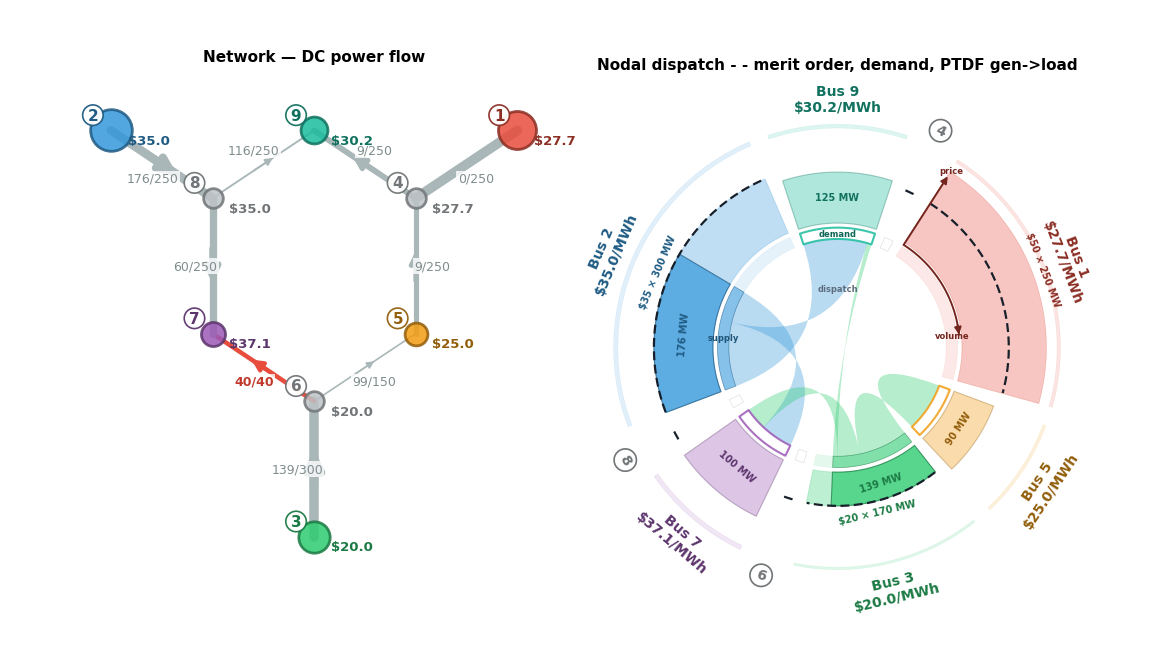

wrote seams_combined_figure.png (600 dpi) and seams_combined_figure.pdf to C:\Users\docke\Projects\ASSUME\assume\testbed

In [9]:
from nodal_plot import plot_combined_letter

binding_lines = {l for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
fig, (ax_net, ax_circ) = plot_combined_letter(
    net, sup, dem,
    bus_colors=colors, bus_lmps=res.lmp,
    line_flows={l: res.flow_own[l] for l in pt.lines},
    line_widths=susceptance_widths(pt), constrained_lines=binding_lines,
    flows=nodal_plot.compute_ptdf_flows(net, sup, dem),
    clearing_price=res.energy_price,
    lmp_line=True,   # dashed line = bus LMP; solid bar height = unit marginal cost
    annotate_roles=True,   # one-time supply/demand/transfers key near 12 o'clock
    axis_key=True,         # illustrative price (up) / volume (across) L-axis in the corner
    all_buses=pt.buses, sector_order=RING_ORDER,
    bus_coords=COORDS, center_bus=CENTER_BUS,   # rotated node diagram + bus 9 at 12 o'clock
    title_right='Nodal dispatch - - merit order, demand, PTDF gen->load',
)
fig.savefig('seams_combined_figure.png', dpi=600, bbox_inches='tight')
fig.savefig('seams_combined_figure.pdf', bbox_inches='tight')   # vector, for Word
plt.show()
print(f'wrote seams_combined_figure.png (600 dpi) and seams_combined_figure.pdf to {os.getcwd()}')

**Read it:** with `line_4` (6–7) limited to 40 MW, the binding internal limit
splits the LMPs — the bus-7 load behind the constraint prices up to ~\$37 while the
cheap bus-3 pocket (\$20) stays low. The congestion term is exactly
$\sum_m SF_{n,m}\,\mu_m$; set `LINE_RATINGS = {}` and re-run to collapse every bus
back to a single energy price.

## 3. Two market footprints on the shared network

The same 9-bus nodal network, now partitioned into **two market footprints**
that clear independently. Each market:

- optimises only its own generators against its own load (plus any scheduled interchange),
- enforces line limits only on its **own** computed flow component $F^M_m$,
- treats the other market's dispatch as exogenous.

The footprints:

- **Market A** = buses {2, 8, 7, 6, 3} — the cheap fleet (gen_1 \$20 @ bus 3,
  gen_0 \$35 @ bus 2) and the load at bus 7 — the natural exporter.
- **Market B** = buses {1, 9, 4, 5} — only the dear unit (gen_slack_0 \$50 @ bus 1)
  and the loads at buses 5 and 9 — the natural importer.

The partition leaves exactly two **seam lines** between the markets: `line_2`
(5-6) and `line_7` (8-9). Every other line is internal to one market.

*Reading the figures below.* Lines are coloured by the market that manages them
(Market A purple, Market B blue); the two seam lines stay grey since neither
market manages them alone, and any line that turns bright red is overloaded,
which overrides its market colour.

In [10]:
# Section 3 config: the two market footprints
MKT_DEFS = {
    'Market A': ['2', '8', '7', '6', '3'],   # cheap fleet (bus 3 $20, bus 2 $35); load at 7 -> exporter
    'Market B': ['1', '9', '4', '5'],         # only the dear bus-1 unit ($50); loads at 5 and 9 -> importer
}
MARKET_COLORS = {'Market A': '#993AFF', 'Market B': '#2471A3'}

bus_to_mkt = {str(b): m for m, buses in MKT_DEFS.items() for b in buses}
mkt_of = lambda b: bus_to_mkt[str(b)]

def line_kind(pt, l):
    # ('internal', market) if both ends share a market, else ('seam', None)
    i = pt.line_idx[l]; b0, b1 = pt.line_buses[i]
    return ('internal', mkt_of(b0)) if mkt_of(b0) == mkt_of(b1) else ('seam', None)

pt = compute_ptdf(build_network(), slack_bus='1')
seam_lines = [l for l in pt.lines if line_kind(pt, l)[0] == 'seam']
internal = {m: [l for l in pt.lines if line_kind(pt, l) == ('internal', m)] for m in MKT_DEFS}

A = make_engine('Market A', MKT_DEFS['Market A'])
B = make_engine('Market B', MKT_DEFS['Market B'])

print('Market A buses:', MKT_DEFS['Market A'], '| internal lines:', internal['Market A'])
print('Market B buses:', MKT_DEFS['Market B'], '| internal lines:', internal['Market B'])
print('seam lines:', [f"{l} ({pt.line_buses[pt.line_idx[l]][0]}-{pt.line_buses[pt.line_idx[l]][1]})" for l in seam_lines])

# -- Market line colours + group map (used by every figure from here on)
def market_line_colors(pt):
    # Internal lines take their managing market's colour; seam lines stay grey.
    out = {}
    for l in pt.lines:
        kind, m = line_kind(pt, l)
        out[l] = MARKET_COLORS[m] if kind == 'internal' else '#AAB7B8'
    return out

MKT_GROUPS = {b: mkt_of(b) for b in pt.buses}   # {bus: market} for circlize banding

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Market A buses:

['2', '8', '7', '6', '3']

| internal lines:

['line_3', 'line_4', 'line_5', 'line_6']

...

['1', '9', '4', '5']

| internal lines:

['line_0', 'line_1', 'line_8']

seam lines:

['line_2 (5-6)', 'line_7 (8-9)']

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


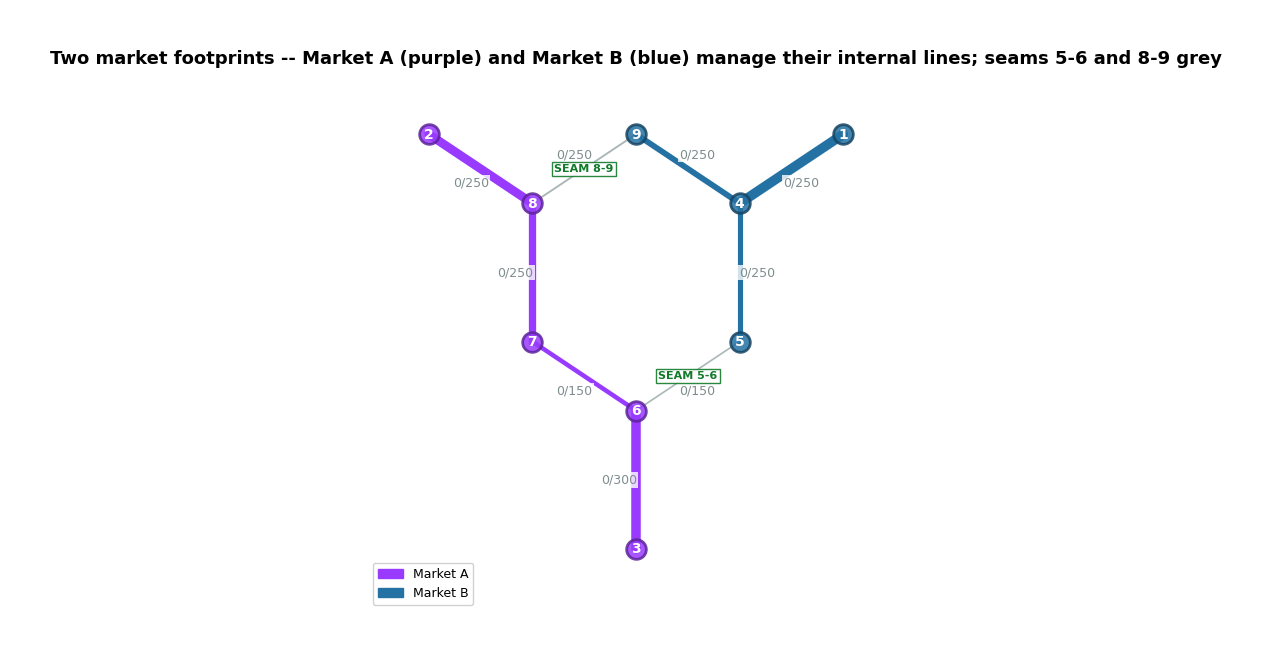

In [11]:
# Map of the two market footprints and the seam lines (buses coloured by market).
mkt_bus_colors = {b: MARKET_COLORS[mkt_of(b)] for b in pt.buses}
fig, ax = plot_network_topology(
    build_network(), supply_by_bus={}, demand_by_bus={},
    bus_colors=mkt_bus_colors, bus_coords=COORDS,
    line_flows={l: 0.0 for l in pt.lines}, line_widths=susceptance_widths(pt),
    line_colors=market_line_colors(pt),   # lines coloured by the managing market; seams grey
    title='Two market footprints -- Market A (purple) and Market B (blue) manage their internal lines; seams 5-6 and 8-9 grey',
)
for l in seam_lines:
    i = pt.line_idx[l]; b0, b1 = pt.line_buses[i]
    x0, y0 = COORDS[b0]; x1, y1 = COORDS[b1]
    ax.text((x0+x1)/2, (y0+y1)/2, f'SEAM {b0}-{b1}', fontsize=8, fontweight='bold',
            color='#117A2B', ha='center', va='center',
            bbox=dict(fc='white', ec='#117A2B', alpha=0.9, pad=1.5), zorder=7)
import matplotlib.patches as mpatches
ax.legend(handles=[mpatches.Patch(color=MARKET_COLORS[m], label=m) for m in MKT_DEFS],
          loc='lower left', fontsize=9, framealpha=0.9)
plt.show()

## 4. Seams issue 1 — dispatch interference

Each market clears on its own footprint with **no interchange scheduled**:
Market A serves its 100 MW load from its cheap units, Market B serves its
215 MW load from the bus-1 unit. Both clears are feasible, and both respect
every line limit they enforce. The wire still overloads.

`line_4` (6-7, internal to Market A) is rated at 40 MW, the same example limit
as Section 2. Market A holds its own flow at exactly 40. Market B's dispatch —
moving power from bus 1 to its loads at buses 5 and 9 — pushes a few extra MW
across line_4 on its way through the meshed network. Market B never looks:
line_4 is not its line. The sum exceeds the rating.

**Edit below:** the line ratings. Interference needs no interchange at all —
that is the point.

### The flow superposition behind the overload

Each market clears the model of Section 2 on its own footprint; the wire carries the sum.

**Each market's own flow — and what it ignores.**

$$F^M_m=\sum_n SF_{n,m}\,p^{\mathrm{inj},M}_n. \qquad\qquad(7)$$

*In words.* Market $M$'s computed flow sums shift factors against **only its own** injections.
The other market's injections contribute **zero** to $F^M_m$ even though their shift factors
are non-zero — the algebraic root of the interference.

**The physical flow is the superposition of both.**

$$F^{\mathrm{phys}}_m=\sum_n SF_{n,m}\,p^{\mathrm{inj,phys}}_n=\sum_{M}F^M_m. \qquad\qquad(8)$$

*In words.* By linearity of DC power flow, the flow that heats the wire is the sum of every
market's component — the `F_phys` column, identical to adding the `F[Market A]` and
`F[Market B]` columns (`physical_flows`).

**What each market enforces vs. what the wire enforces.**

$$\underbrace{\;|F^M_m|\le \bar F_m\ \ \forall M\;}_{\text{each market — its own component}}
  \qquad\Longrightarrow\!\!\!\!\!\diagup\qquad
  \underbrace{\;\Big|\textstyle\sum_M F^M_m\Big|\le \bar F_m\;}_{\text{the wire — the total}} \qquad\qquad(9)$$

*In words.* Each market keeps **its own** component within the rating, but nothing keeps
**their sum** within it — the left does not imply the right. When the two components share a
sign the physical flow can exceed the limit while every market reports a feasible,
within-limits dispatch: the `overload` column. No market-to-market reconciliation is running
here to bring the two clears into agreement before the wire does.

In [12]:
# -- EDIT -- ratings; then the two blind clears (no interchange) -----------
LINE_RATINGS = {'line_4': 40.0}   # the Section-2 limit, internal to Market A
# ---------------------------------------------------------------------------
net = build_network(LINE_RATINGS)
pt  = compute_ptdf(net, slack_bus='1')

rA = solve_engine_dispatch(pt, A)   # no exo: zero scheduled interchange
rB = solve_engine_dispatch(pt, B)

print(f"Market A: dispatch { {g: round(v) for g, v in rA.dispatch.items()} }  energy ${rA.energy_price:.1f}/MWh  cost ${rA.total_cost:,.0f}")
print(f"Market B: dispatch { {g: round(v) for g, v in rB.dispatch.items()} }  energy ${rB.energy_price:.1f}/MWh  cost ${rB.total_cost:,.0f}")
print()
pf = physical_flows(pt, [rA, rB])
cols = ['from', 'to', 'F[Market A]', 'F[Market B]', 'F_phys', 'rating', 'loading_%', 'overload']
print("Line flows -- each market's own component vs the physical total:")
pf[cols]

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Market A: dispatch {'gen_0': 61, 'gen_1': 39}  energy $27.7/MWh  cost $2,909

Market B: dispatch {'gen_slack_0': 215}  energy $50.0/MWh  cost $10,750

Line flows -- each market's own component vs the physical total:

,from,to,F[Market A],F[Market B],F_phys,rating,loading_%,overload
line,,,,,,,,
line_0,1,4,0.0,215.0,215.0,250.0,86.0,False
line_1,4,5,0.6,93.4,94.0,250.0,38.0,False
line_2,5,6,0.6,3.4,4.0,150.0,3.0,False
line_3,3,6,39.4,-0.0,39.4,300.0,13.0,False
line_4,6,7,40.0,3.4,43.4,40.0,109.0,True
line_5,7,8,-60.0,3.4,-56.6,250.0,23.0,False
line_6,8,2,-60.6,0.0,-60.6,250.0,24.0,False
line_7,8,9,0.6,3.4,4.0,250.0,2.0,False
line_8,9,4,0.6,-121.6,-121.0,250.0,48.0,False


In [13]:
ovl = pf[pf.overload]
if len(ovl):
    for ln, row in ovl.iterrows():
        a, b = row['F[Market A]'], row['F[Market B]']
        frm, to, rate, load = row['from'], row['to'], row['rating'], row['loading_%']
        print(f'[!] {ln} ({frm}-{to}): physical |{row.F_phys:.1f}| > {rate:.0f} MW rating ({load:.0f}%)')
        print(f'    Market A sees only {a:+.1f} MW, Market B sees only {b:+.1f} MW -- both within {rate:.0f}, '
              f'neither enforces the real limit.')
else:
    print('No overload at these settings -- tighten LINE_RATINGS.')

[!] line_4 (6-7): physical |43.4| > 40 MW rating (109%)

    Market A sees only +40.0 MW, Market B sees only +3.4 MW -- both within 40, neither enforces the real limit.

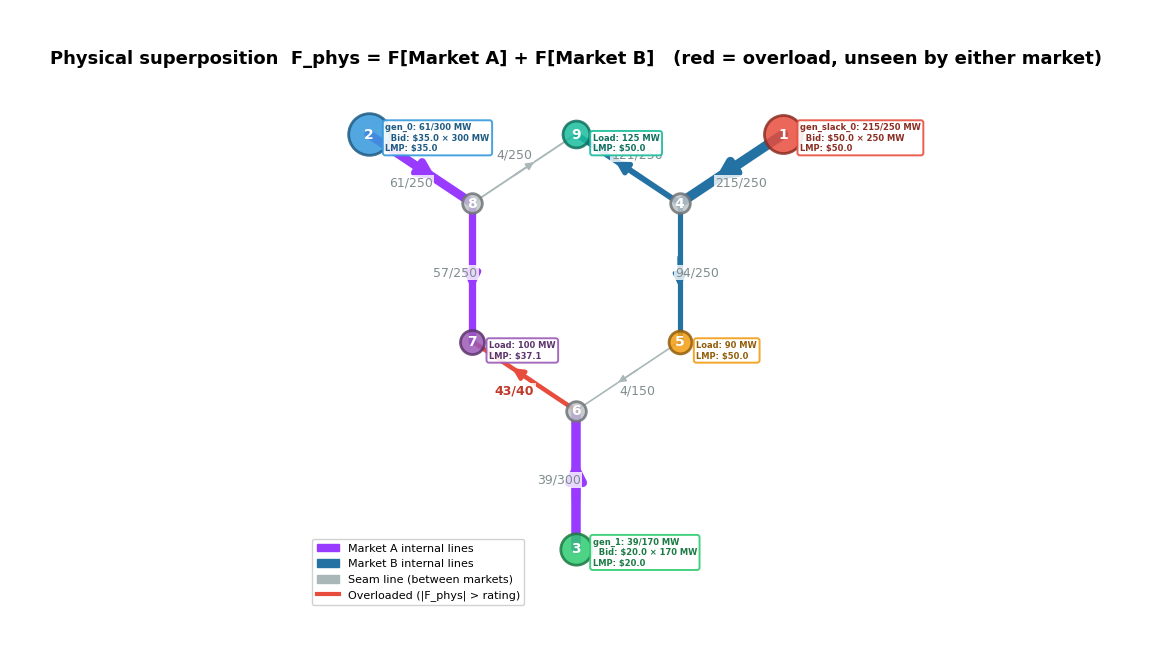

In [14]:
# Visual: physical superposition. Both markets' gens/loads on one map,
# line_flows = the PHYSICAL total. Width = susceptance; red = genuinely
# overloaded (|F_phys| > rating).
sup, dem = {}, {}
for eng, r in [(A, rA), (B, rB)]:
    s, d = to_supply_demand(eng, r); sup.update(s); dem.update(d)
# host LMP for annotation (host = the market that owns the bus)
host_lmp = {}
for r, eng in [(rA, A), (rB, B)]:
    for b in eng.buses: host_lmp[b] = r.lmp[b]
phys = {l: pf.loc[l, 'F_phys'] for l in pt.lines}
overloaded = set(pf[pf.overload].index)
fig, ax = plot_network_topology(
    net, sup, dem, bus_colors=dict(BUS_COLORS), bus_lmps=host_lmp, line_flows=phys,
    line_widths=susceptance_widths(pt), line_colors=market_line_colors(pt),
    constrained_lines=overloaded, bus_coords=COORDS,
    title='Physical superposition  F_phys = F[Market A] + F[Market B]   (red = overload, unseen by either market)',
)
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
ax.legend(handles=[mpatches.Patch(color=MARKET_COLORS[m], label=f'{m} internal lines') for m in MARKET_COLORS]
          + [mpatches.Patch(color='#AAB7B8', label='Seam line (between markets)'),
             Line2D([0], [0], color='#E74C3C', lw=3, label='Overloaded (|F_phys| > rating)')],
          loc='lower left', fontsize=8, framealpha=0.9)
plt.show()

**The point.** Market A's clear and Market B's clear both returned feasible,
within-limits solutions, with no interchange scheduled between them. Yet
`line_4` (6-7) carries ~43 MW on a 40 MW wire, because each market counted only
its own injections (eq. 7) and treated the other's flow as zero. A few MW of
unseen through-flow is all it takes once a line runs near its limit. No
market-to-market reconciliation is running here, so nothing reconciles the two
dispatches before the wire does.

## 5. Seams issue 2 — inefficient accommodation of flows

If Market B's flows cross Market A's wires, Market A can defend its limits by
**reserving room** for them: enforce each internal line not at its full rating,
but at the rating minus the flow it expects the other market to put there. This
is how Available Transfer Capability (ATC) methodologies work — transfer
capability is released to a market only after subtracting expected loop flow
plus a reliability margin.

The reservation restores feasibility, and that is its purpose. The cost is that
the reserved room is **exogenous**: it is fixed before the clear, sized from a
forecast of the other market's dispatch, and padded with a conservatism margin.
Reserve too little and the wire still overloads; reserve too much and
capability that the unified clearing would use sits idle.

### The reservation and the effective limit

**Each market enforces its limits with the other's expected flow already on the wire.**

$$-\bar F_m\le F^M_m+\widehat F^{M'}_m\le \bar F_m,\qquad m\ \text{internal to}\ M. \qquad\qquad(10)$$

*In words.* Market $M$ checks each of its own lines against its own flow plus a fixed
estimate $\widehat F^{M'}_m$ of the other market's flow on that line. The estimate enters the
optimisation as a constant, not a decision variable (`flow_offsets`).

**The reservation is a reference flow times a margin.**

$$\widehat F^{M'}_m=\gamma\,F^{M',\mathrm{ref}}_m,\qquad \gamma\ge 1. \qquad\qquad(11)$$

*In words.* The reference flow $F^{M',\mathrm{ref}}_m$ here is the other footprint's per-line
component in the unified clearing — the best available estimate of how the other market uses
the wire. The margin $\gamma$ is the ATC-style conservatism: it protects against the estimate
being wrong, and its cost is capability withheld from the market.

In [15]:
# -- EDIT -- the reservation each market makes for the other's flows --------
ATC_MARGIN = 1.25    # gamma: 1.0 = reserve exactly the reference flow
# ---------------------------------------------------------------------------

# Reference flow: each footprint's per-line component in the UNIFIED clearing.
uni_cong  = MarketEngine(name='unified', gens={g: dict(s) for g, s in GEN_FLEET.items()},
                         loads=dict(LOADS), activated_lines='all')
runi_cong = solve_engine_dispatch(pt, uni_cong)
comp = {}
for m, buses in MKT_DEFS.items():
    p = np.zeros(pt.n_bus)
    for i, b in enumerate(pt.buses):
        if b in buses: p[i] = runi_cong.injection[i]
    comp[m] = pt.ptdf @ p

# The reservations: {line: signed MW} on each market's internal lines.
# These are plain dicts -- override any entry to refine the rule.
ACCOMMODATION_A = {l: round(float(comp['Market B'][pt.line_idx[l]]) * ATC_MARGIN, 1)
                   for l in internal['Market A']}
ACCOMMODATION_B = {l: round(float(comp['Market A'][pt.line_idx[l]]) * ATC_MARGIN, 1)
                   for l in internal['Market B']}
print('Market A reserves (signed MW):', ACCOMMODATION_A)
print('Market B reserves (signed MW):', ACCOMMODATION_B)
print()

rA_acc = solve_engine_dispatch(pt, A, flow_offsets=ACCOMMODATION_A)
rB_acc = solve_engine_dispatch(pt, B, flow_offsets=ACCOMMODATION_B)
pf_acc = physical_flows(pt, [rA_acc, rB_acc])
print('overloads after accommodation:', pf_acc[pf_acc.overload].index.tolist() or 'none')
print()

rows = [
    {'arrangement': 'blind clears (issue 1)',
     'Market A cost': round(rA.total_cost), 'Market B cost': round(rB.total_cost),
     'sum': round(rA.total_cost + rB.total_cost), 'wire within limits': 'NO -- line_4 overloaded'},
    {'arrangement': f'accommodated (gamma={ATC_MARGIN})',
     'Market A cost': round(rA_acc.total_cost), 'Market B cost': round(rB_acc.total_cost),
     'sum': round(rA_acc.total_cost + rB_acc.total_cost), 'wire within limits': 'yes'},
    {'arrangement': 'unified clearing',
     'Market A cost': '--', 'Market B cost': '--',
     'sum': round(runi_cong.total_cost), 'wire within limits': 'yes'},
]
pd.DataFrame(rows).set_index('arrangement')

Market A reserves (signed MW):

{'line_3': -0.0, 'line_4': 4.3, 'line_5': 4.3, 'line_6': 0.0}

Market B reserves (signed MW):

{'line_0': -268.8, 'line_1': -128.0, 'line_8': 140.8}

overloads after accommodation:

none

,Market A cost,Market B cost,sum,wire within limits
arrangement,,,,
blind clears (issue 1),2909,10750,13659,NO -- line_4 overloaded
accommodated (gamma=1.25),2995,10750,13745,yes
unified clearing,--,--,8941,yes


In [16]:
# The price of conservatism: sweep the ATC margin and watch the cost climb.
rows = []
for g in [1.0, 1.25, 1.5, 2.0]:
    offA = {l: float(comp['Market B'][pt.line_idx[l]]) * g for l in internal['Market A']}
    offB = {l: float(comp['Market A'][pt.line_idx[l]]) * g for l in internal['Market B']}
    try:
        ra = solve_engine_dispatch(pt, A, flow_offsets=offA)
        rb = solve_engine_dispatch(pt, B, flow_offsets=offB)
        pfg = physical_flows(pt, [ra, rb])
        rows.append({'margin gamma': g, 'sum cost': round(ra.total_cost + rb.total_cost),
                     'overloads': ', '.join(pfg[pfg.overload].index.tolist()) or 'none'})
    except RuntimeError:
        rows.append({'margin gamma': g, 'sum cost': None, 'overloads': 'INFEASIBLE'})
lad = pd.DataFrame(rows).set_index('margin gamma')
lad['extra vs gamma=1.0'] = lad['sum cost'] - lad.loc[1.0, 'sum cost']
lad

,sum cost,overloads,extra vs gamma=1.0
margin gamma,,,
1.00,13728,none,0
1.25,13745,none,17
1.50,13762,none,34
2.00,13797,none,69


**Read it.** The accommodation works: the wire is safe, at a combined dispatch
cost a little above the blind clears and far above the unified clearing (the
remaining gap is the unrealised trade, taken up in Section 6). The margin
ladder prices the conservatism: every notch of $\gamma$ moves Market A onto
dearer units to hold room it will almost never need. Notice the size of Market
B's reservations — the unified reference has Market A's generation serving the
whole system, so Market B holds room for flows far larger than anything in its
own dispatch: capability withheld, made visible. And the reservation is
only as good as its reference flow — it was computed from one snapshot of the
other market's dispatch. Change the loads or schedule an interchange and the
snapshot is stale: the wire can overload again with the reservation in place
(try it in the sandbox). Operations diverge from the schedule; a fixed
reservation cannot follow.

## 6. Seams issue 3 — inefficient interchange

Now let the markets trade. A transfer of $E$ MW is scheduled from Market A to
Market B across the seam: from A's optimisation the export is a firm withdrawal
at its seam bus, and from B's optimisation it is a fixed, price-insensitive
injection at its own seam bus — a price taker that does not respond to B's LMP
(a cross-market schedule fixed in advance and frozen during the clear).

Trade is what the seam is for: Market B's load is dear to serve alone and
Market A has cheap spare capacity. Every scheduled MW saves the difference
between the two markets' marginal costs. The question is whether the schedule
reaches the efficient level — and the price signal available to the
participants who schedule it is the **seam dual gap**.

For this section the line ratings revert to their base values, so the only
friction is the interchange itself.

### The price-taking interchange, the seam dual gap, and the cost of the seam

**The interchange is a decision for A but a frozen injection for B.**

$$p^{\mathrm{inj},A}_{n}\ \text{includes}\ -E\ \text{at A's seam bus},\qquad
  p^{\mathrm{inj},B}_{n}\ \text{includes}\ +E\ \text{at B's seam bus},\qquad
  \mathrm{exo}\ \text{fixed before the clear}. \qquad(12)$$

*In words.* From A the export $E$ is a withdrawal it optimises around; to B the same $E$ is a
fixed, price-insensitive injection (`exo`). B's own generation backs down one-for-one as $E$
rises, and the import never re-prices against B's LMP — a price taker.

**Each market prices the same bus through its own dispatch** (the nodal-LMP rule (5) of Section 2):

$$\lambda^A_n=\lambda^A+\!\!\sum_{m\in\mathcal M^A_{\mathrm{act}}}\!\!SF_{n,m}\,\mu^A_m,
  \qquad\qquad
  \lambda^B_n=\lambda^B+\!\!\sum_{m\in\mathcal M^B_{\mathrm{act}}}\!\!SF_{n,m}\,\mu^B_m. \qquad(13)$$

**Seam dual gap.**

$$\Delta\lambda^{A,B}_n:=\lambda^B_n-\lambda^A_n\ \neq\ 0. \qquad\qquad(14)$$

*In words.* The same physical megawatt carries two prices — one per market — and their
difference is generically non-zero **even though the network is shared**. Three things differ
between the markets: the marginal unit (disjoint resource stacks), the set of lines that
bind, and the load each serves. This is the `seam_dual_gap` column.

**The cost of the seam.**

$$W(E)=C^A(E)+C^B(E)-C^{\mathrm{unified}}\ \ge\ 0. \qquad\qquad(15)$$

*In words.* The cost of operating as two markets at interchange $E$ is the gap between the
sum of their independently optimised dispatch costs and the unified clearing's cost. Each
additional scheduled MW lowers $W$ at a rate equal to the seam dual gap at the interchange
buses — trade is worth exactly the price difference it closes — until the gap reaches zero
or the path is fully subscribed. The sweep below shows it: within each price plateau,
every step down in $W$ per MW equals the gap on that row (the row where a marginal unit
switches blends the two rates).

In [17]:
# -- EDIT -- the schedule: seam buses, the sweep, and a contract cap --------
EXPORT_BUS, IMPORT_BUS = '6', '5'     # across seam line_2 (5-6)
E_SWEEP         = [0, 25, 50, 75, 100, 125, 150, 175, 200, 215]
INTERCHANGE_CAP = 215.0               # contract/path cap on the schedule
# ---------------------------------------------------------------------------
net = build_network()                  # base ratings: the seam is the only friction
pt  = compute_ptdf(net, slack_bus='1')

uni  = MarketEngine(name='unified', gens={g: dict(s) for g, s in GEN_FLEET.items()},
                    loads=dict(LOADS), activated_lines='all')
runi = solve_engine_dispatch(pt, uni)

rows, results = [], {}
for E in E_SWEEP:
    E = min(float(E), INTERCHANGE_CAP)
    rA_E = solve_engine_dispatch(pt, A, exo={EXPORT_BUS: -E} if E else None)
    rB_E = solve_engine_dispatch(pt, B, exo={IMPORT_BUS: +E} if E else None)
    results[E] = (rA_E, rB_E)
    gap = rB_E.lmp[IMPORT_BUS] - rA_E.lmp[EXPORT_BUS]
    sumC = rA_E.total_cost + rB_E.total_cost
    rows.append({'E (MW)': E,
                 'lambda_A(export)': round(rA_E.lmp[EXPORT_BUS], 1),
                 'lambda_B(import)': round(rB_E.lmp[IMPORT_BUS], 1),
                 'gap $/MWh': round(gap, 1),
                 'sum cost $': round(sumC),
                 'W(E) $': round(sumC - runi.total_cost)})
sweep = pd.DataFrame(rows).set_index('E (MW)')
print(f'unified clearing cost: ${runi.total_cost:,.0f}.')
print('Check the staircase: within each price plateau, each step down in W per MW equals the gap.')
print('(At E = 215 Market B has no unit left on the margin, so its reported price is a')
print(' degenerate 0 -- the economic gap has just closed.)')
sweep

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


unified clearing cost: $8,475.

Check the staircase: within each price plateau, each step down in W per MW equals the gap.

(At E = 215 Market B has no unit left on the margin, so its reported price is a

 degenerate 0 -- the economic gap has just closed.)

,lambda_A(export),lambda_B(import),gap $/MWh,sum cost $,W(E) $
E (MW),,,,,
0.0,20.0,50.0,30.0,12750,4275
25.0,20.0,50.0,30.0,12000,3525
50.0,20.0,50.0,30.0,11250,2775
75.0,35.0,50.0,15.0,10575,2100
100.0,35.0,50.0,15.0,10200,1725
125.0,35.0,50.0,15.0,9825,1350
150.0,35.0,50.0,15.0,9450,975
175.0,35.0,50.0,15.0,9075,600
200.0,35.0,50.0,15.0,8700,225


In [18]:
# The seam dual gap at every bus, at one operating point of the sweep.
E_SHOW = 150.0
rA_E, rB_E = results[E_SHOW]
gap = seam_dual_gap([rA_E, rB_E], pt.buses)
print(f'E = {E_SHOW:.0f} MW: each bus carries one price per market; the last column is the cross-market basis.')
gap

E = 150 MW: each bus carries one price per market; the last column is the cross-market basis.

,λ[Market A],λ[Market B],Δλ[Market A→Market B]
bus,,,
1,35.0,50.0,15.0
2,35.0,50.0,15.0
3,35.0,50.0,15.0
4,35.0,50.0,15.0
5,35.0,50.0,15.0
6,35.0,50.0,15.0
7,35.0,50.0,15.0
8,35.0,50.0,15.0
9,35.0,50.0,15.0


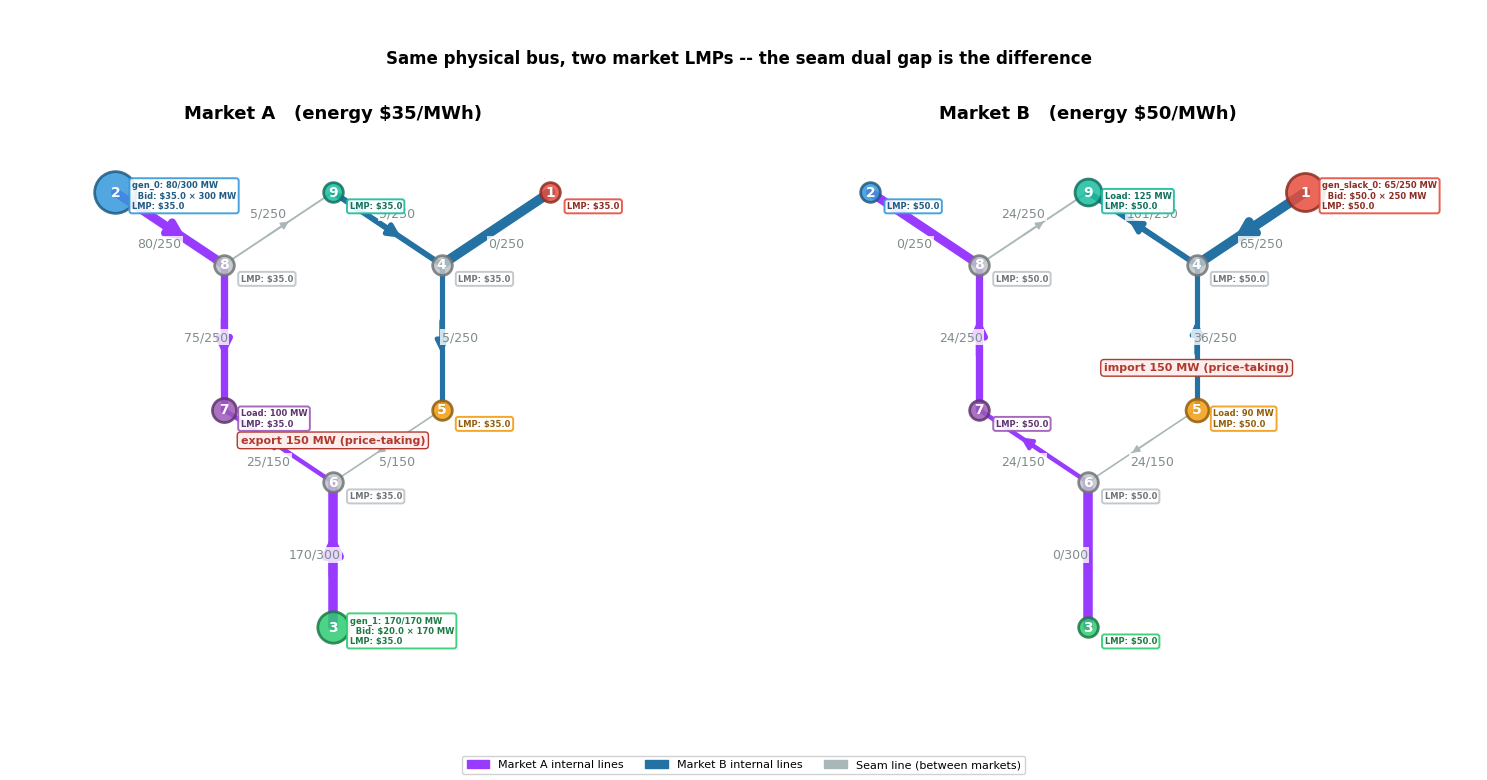

In [19]:
# The two markets side by side: same network, two different LMP fields.
# Width = susceptance (identical on both, it is the shared physics);
# red = that market's own binding lines (shadow price != 0).
wdt = susceptance_widths(pt)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, eng, r in [(axes[0], A, rA_E), (axes[1], B, rB_E)]:
    s, d = to_supply_demand(eng, r)
    exo_note = {EXPORT_BUS: -E_SHOW} if eng is A else {IMPORT_BUS: +E_SHOW}
    bind = {l for l, mu in r.line_dual.items() if abs(mu) > 1e-3}
    plot_network_topology(
        net, s, d, bus_colors=dict(BUS_COLORS), bus_lmps=r.lmp,
        line_flows={l: r.flow_own[l] for l in pt.lines}, line_widths=wdt,
        line_colors=market_line_colors(pt),
        constrained_lines=bind, bus_coords=COORDS, ax=ax,
        title=f'{eng.name}   (energy ${r.energy_price:.0f}/MWh)',
    )
    b = list(exo_note)[0]; mw = exo_note[b]
    label = ('export' if mw < 0 else 'import') + f' {abs(mw):.0f} MW (price-taking)'
    ax.annotate(label, COORDS[b], fontsize=8, fontweight='bold',
                color='#B03A2E', xytext=(0, 28), textcoords='offset points', ha='center',
                bbox=dict(boxstyle='round', fc='#FDEDEC', ec='#B03A2E'))
import matplotlib.patches as mpatches
fig.legend(handles=[mpatches.Patch(color=MARKET_COLORS[m], label=f'{m} internal lines') for m in MARKET_COLORS]
           + [mpatches.Patch(color='#AAB7B8', label='Seam line (between markets)')],
           loc='lower center', ncol=3, fontsize=8, framealpha=0.9)
plt.suptitle('Same physical bus, two market LMPs -- the seam dual gap is the difference',
             fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.show()

**Settlement friction.** A megawatt sold by A and bought by B settles at A's
interface price on one side and B's on the other; with $\Delta\lambda_n\neq0$
the two need not net to the transaction's physical value. A *further* gap
arises at the interface itself, where a generator-weighted aggregation
(CAISO's GAP-Tie) and a load-weighted average (SPP's) summarise the same bus
prices differently — layering on top of this bus-level gap even when the
underlying $\lambda$'s agree.

### Where does the scheduled megawatt actually flow?

The schedule says $E$ MW leaves at bus 6 and arrives at bus 5 — a contract
path. The power itself leaves Market A's generators at buses 2 and 3 and
arrives at Market B's loads at buses 5 and 9, spreading over every parallel
path on the way. The two descriptions load the wires differently.

The cell below re-imposes the Section-4 limit (`line_4` = 40 MW) at $E$ = 150
and computes the flows both ways: once from the markets' scheduled injections
(the contract-path view each market enforces its limits against) and once from
the generators and loads alone (what the wires carry). Each market's own
component respects the limit, and even their scheduled-view sum understates
what the conductor actually carries, because the contract path injects the
transfer at the seam buses while the power actually comes from buses 2 and 3.
A constraint enforced against the contract path protects a fiction. This
transport-layer gap — BA-to-BA schedules standing in for bus-level physics —
is its own seams problem, beyond this notebook's scope.

In [20]:
# Contract-path view vs actual flows, with the Section-4 limit back in place.
E_CP = 150.0
pt_cp = compute_ptdf(build_network({'line_4': 40.0}), slack_bus='1')
rA_cp = solve_engine_dispatch(pt_cp, A, exo={EXPORT_BUS: -E_CP})
rB_cp = solve_engine_dispatch(pt_cp, B, exo={IMPORT_BUS: +E_CP})

# scheduled view: each market's injections, including the +-E at the seam buses
f_sched = pt_cp.ptdf @ (rA_cp.injection + rB_cp.injection)

# actual view: generators and loads only -- the transfer has no bus of its own
p_true = np.zeros(pt_cp.n_bus)
for r in (rA_cp, rB_cp):
    for b, mw in r.gen_by_bus.items():  p_true[pt_cp.bus_idx[b]] += mw
    for b, mw in r.load_by_bus.items(): p_true[pt_cp.bus_idx[b]] -= mw
f_true = pt_cp.ptdf @ p_true

cp = pd.DataFrame({
    'F[Market A]':    np.round([rA_cp.flow_own[l] for l in pt_cp.lines], 1),
    'F[Market B]':    np.round([rB_cp.flow_own[l] for l in pt_cp.lines], 1),
    'scheduled view': np.round(f_sched, 1),
    'actual view':    np.round(f_true, 1),
    'rating':         pt_cp.s_nom,
}, index=pt_cp.lines)
cp['actual overload'] = np.abs(cp['actual view']) > cp['rating'] + 1e-6
print(f'E = {E_CP:.0f} scheduled 6->5, line_4 rated 40 MW:')
cp

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


E = 150 scheduled 6->5, line_4 rated 40 MW:

,F[Market A],F[Market B],scheduled view,actual view,rating,actual overload
line_0,-0.0,65.0,65.0,65.0,250.0,False
line_1,5.5,-36.3,-30.8,6.7,250.0,False
line_2,5.5,23.7,29.2,-83.3,150.0,False
line_3,170.0,-0.0,170.0,170.0,300.0,False
line_4,25.5,23.7,49.2,86.7,40.0,True
line_5,-74.5,23.7,-50.8,-13.3,250.0,False
line_6,-80.0,0.0,-80.0,-80.0,250.0,False
line_7,5.5,23.7,29.2,66.7,250.0,False
line_8,5.5,-101.3,-95.8,-58.3,250.0,False


## 7. The seam ledger — who gains from closing the seam

Four arrangements on the base-ratings network, from no trade to full
integration: autarky ($E=0$), a capped schedule ($E=150$), a near-full schedule
($E=200$), and the unified clearing. For each, the ledger settles every market
at its own LMPs and asks who is better off than under autarky.

Conventions: consumers pay their market's LMP at their bus (shown negative);
generators earn their bus LMP minus marginal cost (producer surplus); the
exporter is paid its own seam-bus price for $E$ and the importer pays its own
seam-bus price for $E$ — the difference, the seam dual gap times $E$, accrues
to whoever holds the schedule (the **trader** column). $W$ is the
dispatch-cost excess over the unified clearing, eq. (15).

In [21]:
# Settle each arrangement at its own prices; positions vs autarky.
def positions(rA_E, rB_E, E):
    out = {}
    for m, r in [('Market A', rA_E), ('Market B', rB_E)]:
        loads_m = {b: LOADS[b] for b in MKT_DEFS[m] if b in LOADS}
        out[(m, 'consumers')] = -sum(r.lmp[b] * mw for b, mw in loads_m.items())
        out[(m, 'generators')] = sum(
            (r.lmp[str(GEN_FLEET[g]['bus'])] - GEN_FLEET[g]['cost']) * mw
            for g, mw in r.dispatch.items())
    out[('Trader', '')] = (rB_E.lmp[IMPORT_BUS] - rA_E.lmp[EXPORT_BUS]) * E
    cost = rA_E.total_cost + rB_E.total_cost
    out[('Total', 'production cost')] = -cost
    out[('Total', 'W vs unified')] = cost - runi.total_cost
    return out

def positions_unified(r):
    out = {}
    for m in MKT_DEFS:
        loads_m = {b: LOADS[b] for b in MKT_DEFS[m] if b in LOADS}
        out[(m, 'consumers')] = -sum(r.lmp[b] * mw for b, mw in loads_m.items())
        out[(m, 'generators')] = sum(
            (r.lmp[str(GEN_FLEET[g]['bus'])] - GEN_FLEET[g]['cost']) * mw
            for g, mw in r.dispatch.items() if str(GEN_FLEET[g]['bus']) in MKT_DEFS[m])
    out[('Trader', '')] = 0.0
    out[('Total', 'production cost')] = -r.total_cost
    out[('Total', 'W vs unified')] = 0.0
    return out

arrangements = {
    'autarky (E=0)':        positions(*results[0.0], 0.0),
    'capped trade (E=150)': positions(*results[150.0], 150.0),
    'near-full (E=200)':    positions(*results[200.0], 200.0),
    'unified clearing':     positions_unified(runi),
}
led = pd.DataFrame(arrangements).T.round(0)
led.columns = pd.MultiIndex.from_tuples(led.columns)
print('Positions ($/h; consumer payments negative):')
display(led)

party_cols = [c for c in led.columns if c[0] in ('Market A', 'Market B', 'Trader')]
delta = led[party_cols] - led[party_cols].loc['autarky (E=0)']
delta['Pareto vs autarky'] = (delta[party_cols] >= -1e-6).all(axis=1).map({True: 'yes', False: 'NO'})
print('Change vs autarky (who gains, who loses):')
delta

Positions ($/h; consumer payments negative):

Market A             Market B             Trader           Total             
                     consumers generators consumers generators         production cost W vs unified
autarky (E=0)          -2000.0        0.0  -10750.0        0.0     0.0        -12750.0       4275.0
capped trade (E=150)   -3500.0     2550.0  -10750.0        0.0  2250.0         -9450.0        975.0
near-full (E=200)      -3500.0     2550.0  -10750.0        0.0  3000.0         -8700.0        225.0
unified clearing       -3500.0     2550.0   -7525.0        0.0     0.0         -8475.0          0.0

Change vs autarky (who gains, who loses):

Market A             Market B             Trader Pareto vs autarky
                     consumers generators consumers generators                          
autarky (E=0)              0.0        0.0       0.0        0.0     0.0               yes
capped trade (E=150)   -1500.0     2550.0       0.0        0.0  2250.0                NO
near-full (E=200)      -1500.0     2550.0       0.0        0.0  3000.0                NO
unified clearing       -1500.0     2550.0    3225.0        0.0     0.0                NO

**Read it.** Trade shrinks the production-cost bill monotonically — $W$ falls
to zero at the unified clearing — but the gains land unevenly, and where they
land depends on the arrangement. Under the scheduled trades, Market B's
consumers gain nothing at all: the import settles at Market B's own marginal
price, still set by the bus-1 unit, so the entire trade surplus accrues to
Market A's generators and the trader holding the schedule. Only the unified
clearing passes the cheap generation through to Market B's load (its price
falls from \$50 to \$35). Market A's consumers lose in every arrangement:
exporting raises their own price from \$20 to \$35, the classic
exporting-region distributional result. Integration is efficient in total and
not automatically a Pareto improvement — making every party whole takes a side
instrument (contracts for differences, congestion-revenue rights, or an agreed
allocation of the trade surplus), which is a design choice the dispatch itself
does not make.

## 8. Sandbox

One cell, every knob. Reassign buses to markets, change which constraints each
market *activates* (`activated_lines` = the discretionary set
$\mathcal M^M_{\text{act}}$), move the interchange, re-bid units, and switch
the accommodation on or off. Re-run to see prices, overloads, and the dual gap
move.

In [22]:
# -- EDIT -- free-form two-market experiment ---------------------------------
RATINGS        = {'line_4': 40.0}
A_BUSES        = ['2', '8', '7', '6', '3']
B_BUSES        = ['1', '9', '4', '5']
A_ACTIVATED    = 'all'        # or a list, e.g. ['line_4'] -> A ignores the rest
B_ACTIVATED    = 'all'
COSTS          = {}           # {'gen_1': 30.0}
LOADS_OVERRIDE = {}           # {'9': 160.0}
E_MW           = 0.0          # scheduled interchange A -> B
TIE            = ('6', '5')   # (export bus in A, import bus in B)
ACC_MARGIN     = 0.0          # 0 = blind; try 1.0 or 1.25 (one-shot forecast reservation)
# ----------------------------------------------------------------------------
net = build_network(RATINGS); pt = compute_ptdf(net, slack_bus='1')
for b, v in LOADS_OVERRIDE.items(): LOADS[b] = v
A_x = make_engine('Market A', A_BUSES, activated=A_ACTIVATED)
B_x = make_engine('Market B', B_BUSES, activated=B_ACTIVATED)
for eng in (A_x, B_x):
    for g, c in COSTS.items():
        if g in eng.gens: eng.gens[g]['cost'] = c

def _kind(l):
    i = pt.line_idx[l]; b0, b1 = pt.line_buses[i]
    a, bb = set(map(str, A_BUSES)), set(map(str, B_BUSES))
    if b0 in a and b1 in a: return 'A'
    if b0 in bb and b1 in bb: return 'B'
    return 'seam'

exoA = {TIE[0]: -E_MW} if E_MW else None
exoB = {TIE[1]: +E_MW} if E_MW else None
offA = offB = None
if ACC_MARGIN > 0:   # reserve the other's blind-forecast component on internal lines
    rA1 = solve_engine_dispatch(pt, A_x, exo=exoA)
    rB1 = solve_engine_dispatch(pt, B_x, exo=exoB)
    offA = {l: rB1.flow_own[l] * ACC_MARGIN for l in pt.lines if _kind(l) == 'A'}
    offB = {l: rA1.flow_own[l] * ACC_MARGIN for l in pt.lines if _kind(l) == 'B'}
rA_s = solve_engine_dispatch(pt, A_x, exo=exoA, flow_offsets=offA)
rB_s = solve_engine_dispatch(pt, B_x, exo=exoB, flow_offsets=offB)
print('A energy', round(rA_s.energy_price, 1), '| B energy', round(rB_s.energy_price, 1))
pf_s = physical_flows(pt, [rA_s, rB_s])
print('overloads:', pf_s[pf_s.overload].index.tolist() or 'none')
display(seam_dual_gap([rA_s, rB_s], pt.buses))
pf_s[['from', 'to', 'F[Market A]', 'F[Market B]', 'F_phys', 'rating', 'loading_%', 'overload']]

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


A energy

27.7

| B energy

50.0

overloads:

['line_4']

,λ[Market A],λ[Market B],Δλ[Market A→Market B]
bus,,,
1,27.74,50.0,22.26
2,35.00,50.0,15.00
3,20.00,50.0,30.00
4,27.74,50.0,22.26
5,25.02,50.0,24.98
6,20.00,50.0,30.00
7,37.13,50.0,12.87
8,35.00,50.0,15.00
9,30.25,50.0,19.75


,from,to,F[Market A],F[Market B],F_phys,rating,loading_%,overload
line,,,,,,,,
line_0,1,4,0.0,215.0,215.0,250.0,86.0,False
line_1,4,5,0.6,93.4,94.0,250.0,38.0,False
line_2,5,6,0.6,3.4,4.0,150.0,3.0,False
line_3,3,6,39.4,-0.0,39.4,300.0,13.0,False
line_4,6,7,40.0,3.4,43.4,40.0,109.0,True
line_5,7,8,-60.0,3.4,-56.6,250.0,23.0,False
line_6,8,2,-60.6,0.0,-60.6,250.0,24.0,False
line_7,8,9,0.6,3.4,4.0,250.0,2.0,False
line_8,9,4,0.6,-121.6,-121.0,250.0,48.0,False


---
*Computation: [`seams_engine.py`](seams_engine.py) (PTDF DC-OPF, dual-derived LMPs).
Network: [`ieee9_network.py`](ieee9_network.py). Plots: [`nodal_plot.py`](nodal_plot.py).
Validated against an independent Egret SCED solution.*